In [11]:
import os
from torchvision import io, utils
from pycocotools.coco import COCO
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from pycocotools.cocoeval import COCOeval
from torchvision.datasets import CocoDetection
import torch
from torchvision.transforms.functional import to_tensor
import pytorch_lightning as pl
import json
import pandas as pd 

from ultralytics import YOLO

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# PARAMETERS
NUM_CLASSES = 8 # 7 classes + background
EPOCHS = 100
MODEL_TYPE = "yolov11"
VERSION = "1_puro"
CHECKPOINT = "./SVRDD_YOLO11m/weights/best.pt"
EVALUATION_RESULTS_FOLDER = "./evaluation_results"


# Caminhos do dataset
ROOT_DIR = "../../SVRDD_COCO"
TRAIN_DIRECTORY = os.path.join(ROOT_DIR, "train")
VAL_DIRECTORY = os.path.join(ROOT_DIR, "valid")
TEST_DIRECTORY = os.path.join(ROOT_DIR, "test")
ANNOTATION_FILE_NAME = "_annotations.coco.json"
DETECTIONS_PATH = "detections.json"
CLASSES = {
    0: "longitudinal crack",
    1: "transverse crack",
    2: "alligator crack",
    3: "pothole",
    4: "manhole cover",
    5: "longitudinal patch",
    6: "transverse patch",
}

In [ ]:
#model = YOLO("/home/andre/TCC/models/YOLOv11/SVRDD_YOLO11m/weights/best.pt")
#model.val(data="/home/andre/TCC/SVRDD_YOLO/data.yaml")

In [9]:
def count_classes(coco_gt):
    # --- Contagem de instâncias ---
    cat_ids = coco_gt.getCatIds()
    cats = [coco_gt.loadCats([i])[0]["name"] for i in cat_ids]
    area_labels = ["small", "medium", "large"]

    counts_dict = {cat: {"small":0, "medium":0, "large":0} for cat in cats}
    ann_ids = coco_gt.getAnnIds()
    anns = coco_gt.loadAnns(ann_ids)

    for ann in anns:
        cat_name = coco_gt.loadCats([ann["category_id"]])[0]["name"]
        area = ann["area"]
        if area < 32**2:
            counts_dict[cat_name]["small"] += 1
        elif area < 96**2:
            counts_dict[cat_name]["medium"] += 1
        else:
            counts_dict[cat_name]["large"] += 1
    return cats, counts_dict


def evaluate_coco(dataset_dir, json_detection_path, excel_path="coco_results.xlsx"):

    GT_ANN_FILE = os.path.join(dataset_dir, ANNOTATION_FILE_NAME)

    # carregar ground truth
    coco_gt = COCO(GT_ANN_FILE)

    # carregar detecções
    coco_dt = coco_gt.loadRes(json_detection_path)

    # rodar avaliação
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    # métricas por classe
    cats, counts_dict = count_classes(coco_gt)

    # Converter para DataFrame
    df_counts = pd.DataFrame(counts_dict).T
    df_counts["total"] = df_counts.sum(axis=1)
    df_counts = df_counts[["total", "small", "medium", "large"]]
    print("\n=== Contagem de instâncias por classe e tamanho ===")
    print(df_counts)

    # --- Tabelas de métricas ---
    precisions = coco_eval.eval['precision']  # [TxRxKxAxM]
    iou_thrs = coco_eval.params.iouThrs
    iou50_idx = np.where(iou_thrs == 0.5)[0][0]
    maxDets_idx = 2  # normalmente corresponde a 100 maxDets
    area_labels_full = ["all", "small", "medium", "large"]
    metrics_tables = {}
    
    for a_idx, area in enumerate(area_labels_full):
        data = []
        for idx, cat in enumerate(cats):
            # mAP 0.50:0.95
            precision_all = precisions[:, :, idx, a_idx, maxDets_idx]
            precision_all = precision_all[precision_all > -1]
            mAP = np.mean(precision_all) if precision_all.size > 0 else np.nan

            # mAP50
            precision50 = precisions[iou50_idx, :, idx, a_idx, maxDets_idx]
            precision50 = precision50[precision50 > -1]
            mAP50 = np.mean(precision50) if precision50.size > 0 else np.nan

            # quantidade
            if area == "all":
                qty = df_counts.loc[cat, "total"]
            else:
                qty = df_counts.loc[cat, area]

            data.append([qty, mAP50, mAP])

        df_metrics = pd.DataFrame(data, columns=["Quantidade", "mAP50", "mAP50:0.95"], index=cats)
        metrics_tables[area] = df_metrics
        print(f"\n=== Métricas para tamanho '{area}' ===")
        print(df_metrics.round(3))

    # --- Exportar tudo para Excel ---
    with pd.ExcelWriter(excel_path) as writer:
        df_counts.round(3).to_excel(writer, sheet_name="counts")
        for area, df in metrics_tables.items():
            df.round(3).to_excel(writer, sheet_name=area)

    print(f"\n📁 Arquivo Excel exportado com sucesso para: {excel_path}")
    return coco_eval

def get_one_example_prediction(image_id: int, results: list):
    pred_box = []
    pred_label = []
    pred_score = []
    for i in range(len(results)):
        # Pegar todas as boxes , labels e scores do resultado que tiver image_id == x
        if results[i]["image_id"] == image_id + 1:
            pred_box.append(results[i]["bbox"])
            pred_label.append(results[i]["category_id"])
            pred_score.append(results[i]["score"])
        elif results[i]["image_id"] > image_id + 1:
            break

    pred_box = torch.tensor(pred_box)
    pred_label = torch.tensor(pred_label)
    pred_score = torch.tensor(pred_score)
    return pred_box, pred_label, pred_score

def coco_load_image(img_info: dict, dataset_dir: str):
    # Getting image tensor
    img_path = os.path.join(dataset_dir, img_info["file_name"])
    image = Image.open(img_path).convert("RGB")
    img_tensor = to_tensor(image).to(device)
    return img_tensor

def get_image_and_target(image_id: int, dataset_dir: str):
    
    # Getting dataset on coco format
    coco = COCO(os.path.join(dataset_dir, ANNOTATION_FILE_NAME))

    # Getting image tensor
    coco_img_id = coco.getImgIds()[image_id]
    img_info = coco.loadImgs(coco_img_id)[0]
    img_tensor = coco_load_image(img_info, dataset_dir)

    # Getting annotation target
    ann_ids = coco.getAnnIds(imgIds=coco_img_id)
    anns = coco.loadAnns(ann_ids)
    target = {
        "boxes": torch.tensor([ann["bbox"] for ann in anns], dtype=torch.float32).to(device),
        "labels": torch.tensor([ann["category_id"] for ann in anns], dtype=torch.int64).to(device),
    }
    target["boxes"][:, 2] = target["boxes"][:, 0] + target["boxes"][:, 2]
    target["boxes"][:, 3] = target["boxes"][:, 1] + target["boxes"][:, 3]
    return img_tensor, target


# YOLOv11

In [17]:
EVALUATE_DIRECTORY = TRAIN_DIRECTORY
threshold = 0.0
REEVALUATE = False

os.makedirs(EVALUATION_RESULTS_FOLDER, exist_ok=True)
json_detection_file = f'{os.path.basename(EVALUATE_DIRECTORY)}_{MODEL_TYPE}_{VERSION}_{DETECTIONS_PATH}'
json_detection_path = os.path.join(EVALUATION_RESULTS_FOLDER, json_detection_file) 
if REEVALUATE or not os.path.isfile(json_detection_path):
    
    ###################################################
    # Instantiating model                             #
    ###################################################
    
    model = YOLO(CHECKPOINT).to(device)
    
    ###################################################
    # Predicting model                                #
    ###################################################
    print("Predicting on Evaluation Dataset...")
    predictions = model.predict(
        source=EVALUATE_DIRECTORY,
        stream=True,
        verbose=False,   # reduz logs
    )


    ###################################################
    # Getting Results                                #
    ###################################################
    all_preds = []
    for img_id, r in enumerate(predictions):
        xyxy = r.boxes.xyxy.cpu().numpy()
        cls = r.boxes.cls.cpu().numpy()
        conf = r.boxes.conf.cpu().numpy()
    
        # converter para COCO xywh
        boxes = xyxy.copy()
        boxes[:,2] = xyxy[:,2] - xyxy[:,0]
        boxes[:,3] = xyxy[:,3] - xyxy[:,1]
    
        for b, c, s in zip(boxes, cls, conf):
            all_preds.append({
                "image_id": img_id + 1,
                "category_id": int(c),
                "bbox": b.tolist(),
                "score": float(s)
            })
    with open(json_detection_path, "w") as f:
        json.dump(all_preds, f)

Predicting on Evaluation Dataset...


In [18]:
excel_path = json_detection_path.replace(DETECTIONS_PATH, "coco_results.xlsx")
evaluate_coco(EVALUATE_DIRECTORY, json_detection_path, excel_path=excel_path)

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.50s).
Accumulating evaluation results...
DONE (t=0.23s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.663
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.883
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.772
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.435
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.651
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.786
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.520
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.712
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

## Example Prediction

Getting one example prediction...
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Visualizing Prediction...
Visualizing GroundTruth...


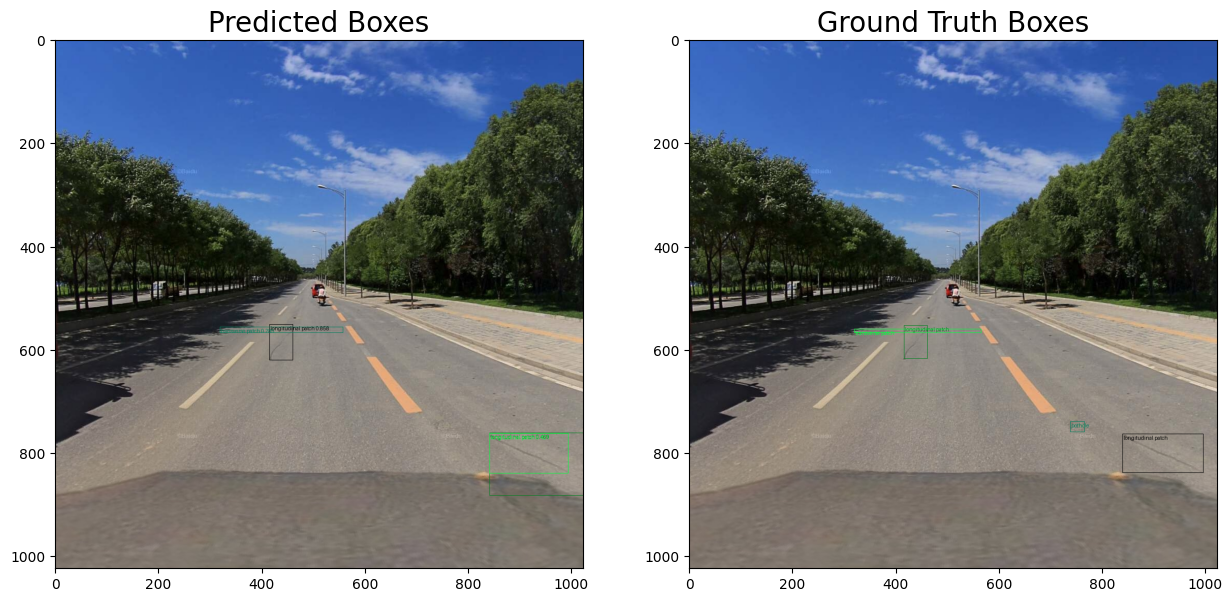

In [13]:
# Example Prediction
image_id = 50
threshold = 0.25

with open(DETECTIONS_PATH) as f:
    all_preds = json.load(f)
    
print("Getting one example prediction...")
pred_box, pred_label, pred_score = get_one_example_prediction(image_id, all_preds)

# Adjust to best threshold
keep = pred_score >= threshold
boxes = pred_box[keep]
labels = pred_label[keep]
scores = pred_score[keep]

# Convert boxes from COCO format [x, y, w, h] to xyxy [xmin, ymin, xmax, ymax]
boxes[:, 2] = boxes[:, 0] + boxes[:, 2]
boxes[:, 3] = boxes[:, 1] + boxes[:, 3]

# Getting image and annotation target
img_tensor, target = get_image_and_target(image_id, EVALUATE_DIRECTORY)

print("Visualizing Prediction...")
# Visualize predictions.
image_with_boxes = utils.draw_bounding_boxes(
    image=(img_tensor * 255).to(torch.uint8),
    boxes=boxes,
    labels=[f"{CLASSES[label.item()]} {score:.3f}" for label, score in zip(labels, scores)],
)

fig, ax = plt.subplots(1, 2, figsize=(15, 15))
ax[0].imshow(image_with_boxes.permute(1, 2, 0))

print("Visualizing GroundTruth...")
# Visualize predictions.
image_with_boxes = utils.draw_bounding_boxes(
    image=(img_tensor * 255).to(torch.uint8),
    boxes=target["boxes"],
    labels=[f"{CLASSES[label.item()]}" for label in target["labels"]],
)

# Colocar título nas imagens
ax[0].set_title("Predicted Boxes", fontsize=20)
ax[1].set_title("Ground Truth Boxes", fontsize=20)
ax[1].imshow(image_with_boxes.permute(1, 2, 0))
fig.savefig("pred_ground_truth.png")
plt.show()